In [2]:
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
load_dotenv()

True

In [4]:
# carregando dataset de players valuations
path = os.getenv('DATASETS_PATH')
df = pd.read_csv(path + '/player_valuations.csv')
df.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057.0,BE1
1,342216,2001-07-20,100000,Unknown,1241.0,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1
3,6893,2003-12-15,900000,Galatasaray,984.0,GB1
4,10,2004-10-04,7000000,SV Werder Bremen,398.0,IT1


In [5]:
# quantidade de valores
df.count()

player_id                              656301
date                                   656301
market_value_in_eur                    656301
current_club_name                      656301
current_club_id                        656300
player_club_domestic_competition_id    563289
dtype: int64

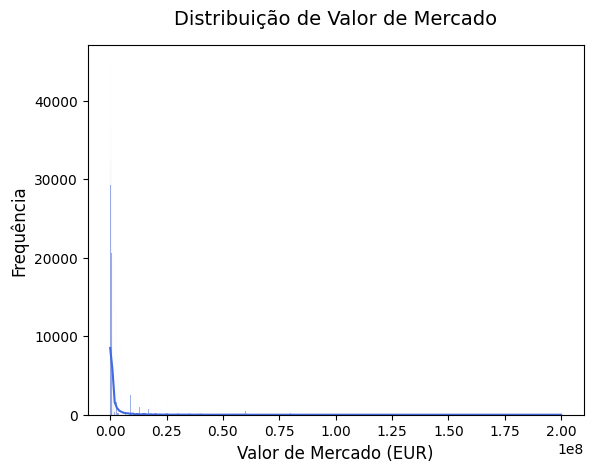

In [6]:
# dataframe com valores acima de 0 em valor de mercado
df_temp = df[df['market_value_in_eur'] > 0].dropna(subset=['market_value_in_eur'])

# histograma simples com a distribuição de valor de mercado
sns.histplot(data=df_temp, x='market_value_in_eur', kde=True, color='royalblue');

# Customização de títulos e eixos
plt.title('Distribuição de Valor de Mercado', fontsize=14, pad=15)
plt.xlabel('Valor de Mercado (EUR)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/distribution_market_value.png', dpi=300, bbox_inches='tight')
plt.show()

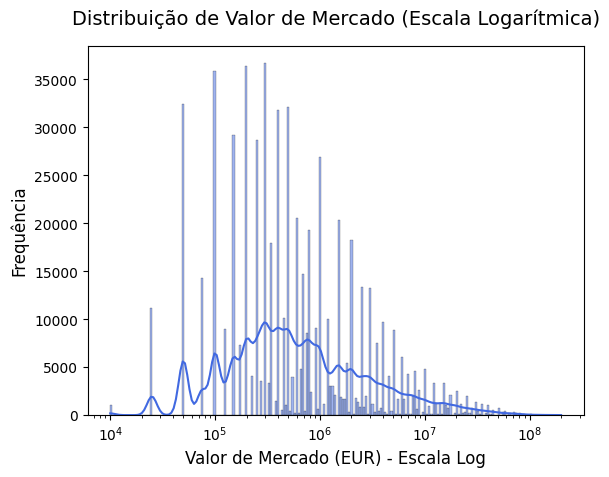

In [7]:
# dataframe com valores acima de 0 em valor de mercado
df_temp = df[df['market_value_in_eur'] > 0].dropna(subset=['market_value_in_eur'])

# histografico com a distribuição de valor de mercado
sns.histplot(data=df_temp, x='market_value_in_eur', log_scale=True, kde=True, color='royalblue');

# Customização de títulos e eixos
plt.title('Distribuição de Valor de Mercado (Escala Logarítmica)', fontsize=14, pad=15)
plt.xlabel('Valor de Mercado (EUR) - Escala Log', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/distribution_market_value_log.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# modificando para o formato de data correto e criando a tabela year
df_temp = df
df_temp['year'] = pd.to_datetime(df_temp['date']).dt.year
df_temp.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id,year
0,405973,2000-01-20,150000,Unknown,3057.0,BE1,2000
1,342216,2001-07-20,100000,Unknown,1241.0,SC1,2001
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1,2003
3,6893,2003-12-15,900000,Galatasaray,984.0,GB1,2003
4,10,2004-10-04,7000000,SV Werder Bremen,398.0,IT1,2004


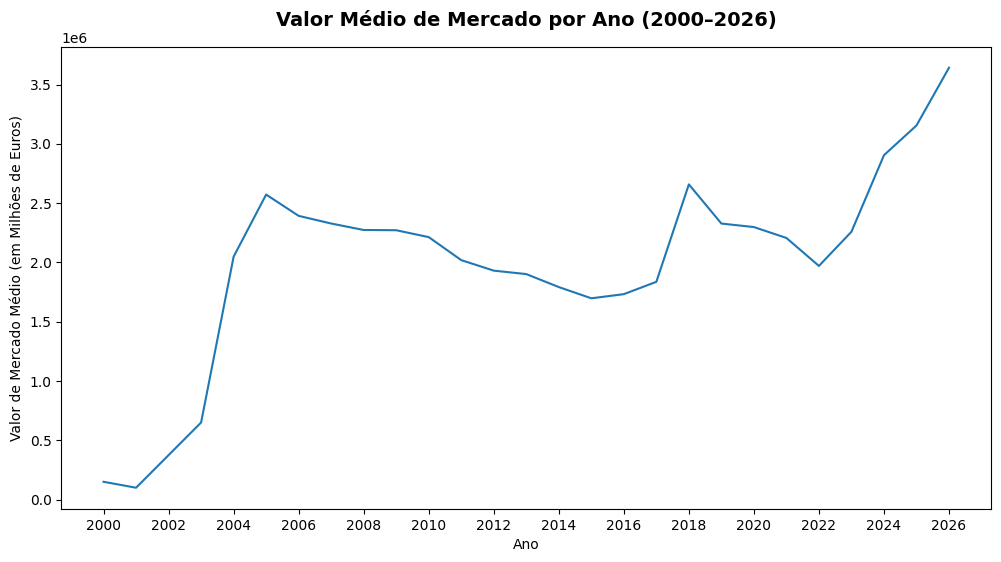

In [9]:
# Calculando o valor médio por ano
mvby = df_temp.groupby('year')['market_value_in_eur'].mean()

# Configurações visuais do gráfico
plt.figure(figsize=(12, 6))
plt.plot(mvby)
plt.title('Valor Médio de Mercado por Ano (2000–2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ano')
plt.ylabel('Valor de Mercado Médio (em Milhões de Euros)')
plt.xticks(range(2000, 2027, 2))

# exibe o grafico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/mean_market_value_by_year.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
# quantidade de jogadores únicos
df["player_id"].nunique()

41528

In [11]:
# média de avaliações por jogador
df.groupby("player_id").size().mean()

15.803819109998074

In [12]:
# modificando para o formato de data correto e criando a tabela year
df_temp = df
df_temp['year'] = pd.to_datetime(df_temp['date']).dt.year
df_temp.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id,year
0,405973,2000-01-20,150000,Unknown,3057.0,BE1,2000
1,342216,2001-07-20,100000,Unknown,1241.0,SC1,2001
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1,2003
3,6893,2003-12-15,900000,Galatasaray,984.0,GB1,2003
4,10,2004-10-04,7000000,SV Werder Bremen,398.0,IT1,2004


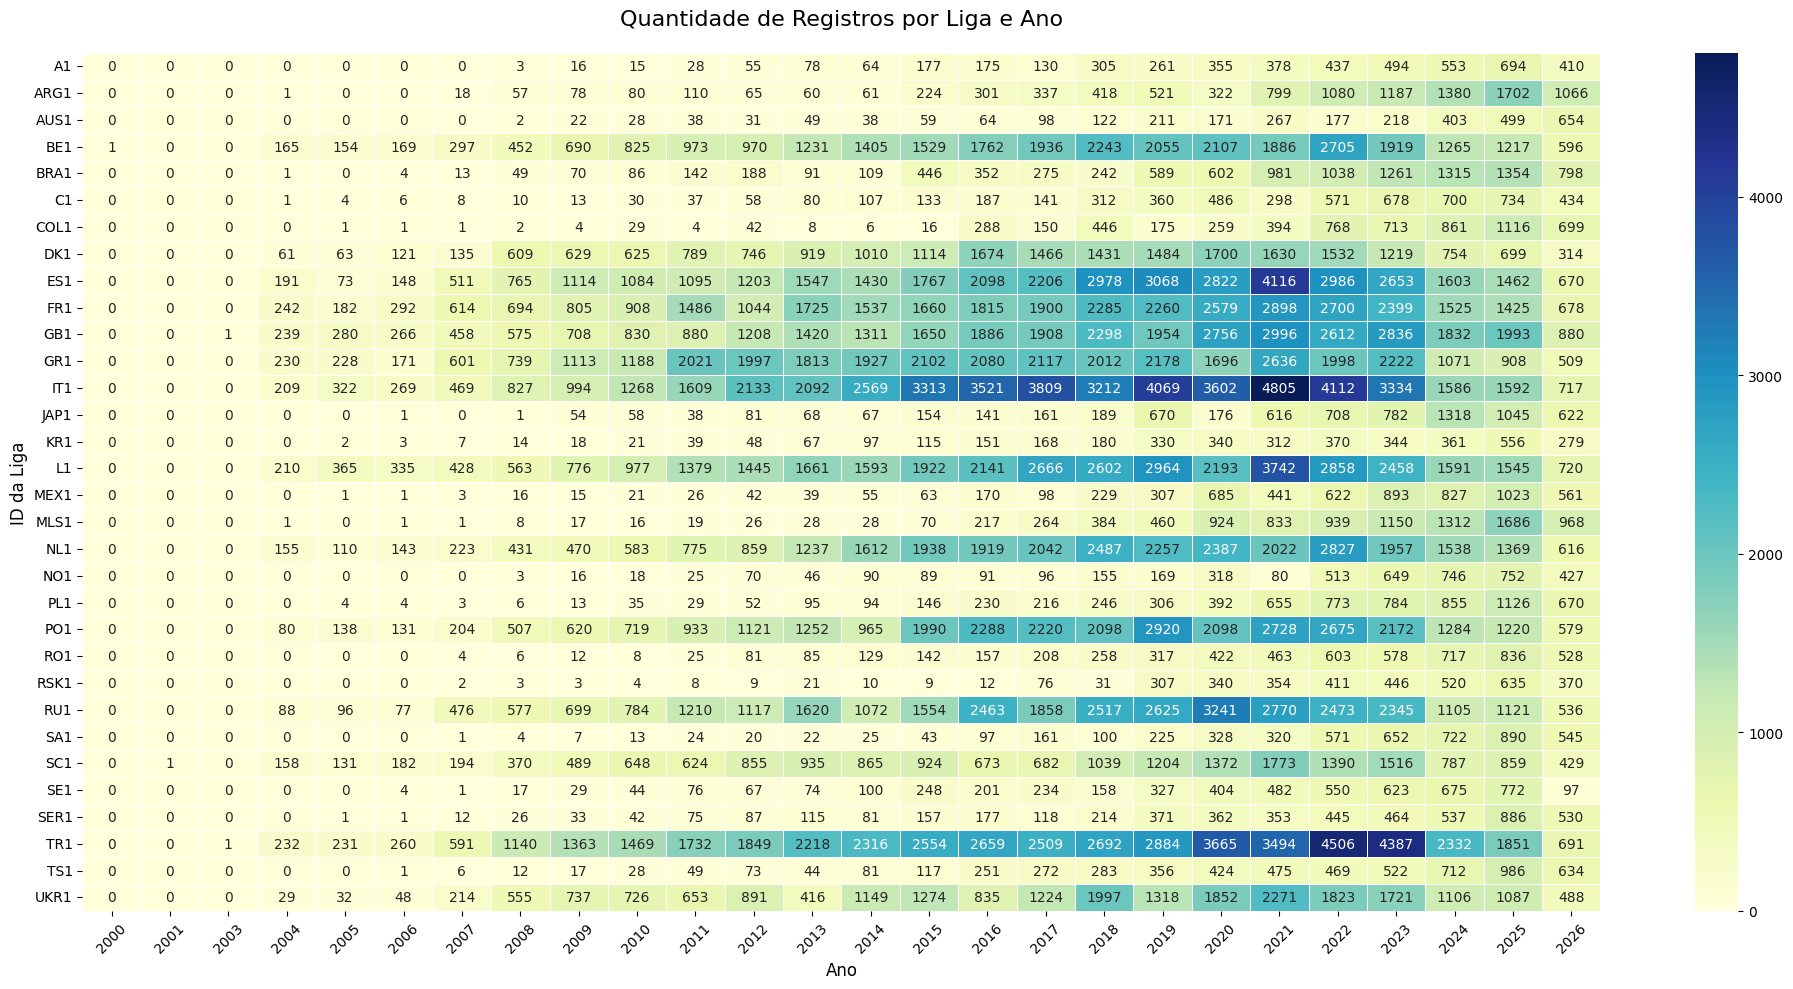

In [13]:
# cruza os anos com as ligas em uma pivot table
pivot_table = df_temp.pivot_table(
    index='player_club_domestic_competition_id', 
    columns='year', 
    values='player_id', 
    aggfunc='count', 
    fill_value=0
)

# plotando um mapa de calor
plt.figure(figsize=(20, 10))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Quantidade de Registros por Liga e Ano', fontsize=16, pad=20)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('ID da Liga', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# exibe o grafico e salva
plot_path = os.getenv('PLOTS_PATH')
plt.savefig(plot_path + '/records_by_league_year.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# vendo quantos valores nulos tem no geral
df.isna().sum()

player_id                                  0
date                                       0
market_value_in_eur                        0
current_club_name                          0
current_club_id                            1
player_club_domestic_competition_id    93012
year                                       0
dtype: int64

In [15]:
# valor máximo de um jogador avaliado
df['market_value_in_eur'].max()

200000000

In [16]:
# valor mínimo de um jogador avaliado
df['market_value_in_eur'].min()

0

In [17]:
# valor médio dos jogadores avaliados
df['market_value_in_eur'].mean()

2290092.5535676465

In [18]:
# mediana
df['market_value_in_eur'].median()

500000.0